             type  num_fields  num_rows     runtime  fields_per_sec  \
0  initial_import     1122000     21000  231.090930     4855.231662   
1  initial_import     1122000     21000  262.962417     4266.769424   
2  initial_import     1122000     21000  396.636181     2828.788833   
3  initial_import     1122000     21000  561.186455     1999.335497   

   rows_per_sec  dtus  
0     90.873320     1  
1     79.859321     2  
2     52.945246     3  
3     37.420718     4  


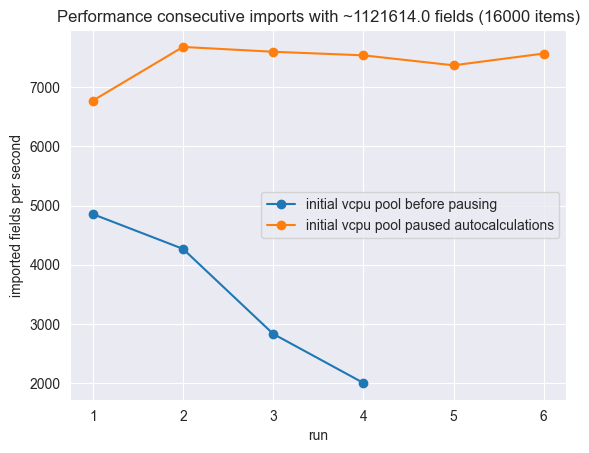

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path = "caches/stats/import_12vcpu.csv"

df = pd.read_csv(path)

dtu_config = [1,2,3,4]

df_initial= df[df["type"] == "initial_import"]
df_initial["dtus"] = dtu_config
# df_diff= df[df["type"] == "differential_import"]
# df_diff["dtus"] = dtu_config

fields_per_import = 2327*964/2
num_items = 1000*16
print(df_initial)

plt.plot(df_initial["dtus"], df_initial["fields_per_sec"], label="initial vcpu pool before pausing", marker="o")

path = "caches/stats/import_paused_calcs.csv"

df = pd.read_csv(path)

dtu_config = [1,2,3,4,5,6]

df_initial= df[df["type"] == "initial_import"]
df_initial["dtus"] = dtu_config
plt.plot(df_initial["dtus"], df_initial["fields_per_sec"], label="initial vcpu pool paused autocalculations", marker="o")
# plt.plot(df_diff["dtus"], df_diff["fields_per_sec"], label="differential import", marker="o")
plt.legend()
plt.title(f"Performance consecutive imports with ~{fields_per_import} fields ({num_items} items)")
plt.xlabel("run")
plt.ylabel("imported fields per second")
plt.savefig("caches/plots/import_paused_calcs.png")
plt.show()